# Comparison of the results from `MCube` on different CRC datasets focusing on CD4+ T cells and CD8+ T cells

In [1]:
set.seed(20250502)

library(Matrix)
library(spacexr)
library(MCube)
library(ggplot2)

palettes <- c("#32CD32", "#FF69B4")

In [2]:
RAW_DATA_PATH <- "/import/home/share/zw/data/CRC"
DATA_PATH <- "/import/home/share/zw/pql/data/CRC"
RESULT_PATH <- "/import/home/share/zw/pql/results/CRC"

if (!dir.exists(file.path(RESULT_PATH, "Visium"))) {
    dir.create(file.path(RESULT_PATH, "Visium"), recursive = TRUE)
}
if (!dir.exists(file.path(RESULT_PATH, "VisiumHD"))) {
    dir.create(file.path(RESULT_PATH, "VisiumHD"), recursive = TRUE)
}
if (!dir.exists(file.path(RESULT_PATH, "Xenium"))) {
    dir.create(file.path(RESULT_PATH, "Xenium"), recursive = TRUE)
}

We then compare the results from `MCube` on different CRC datasets.
We focus on the CD4+ T cells and CD8+ T cells to study the tumor microenvironment (TME).

In [3]:
immune_celltypes <- c("CD4 T cell", "CD8 Cytotoxic T cell")

## 10x Visium

In [4]:
tech <- "Visium"

### Cell type deconvolution using `RCTD`

In [5]:
myRCTD <- readRDS(file.path(RESULT_PATH, tech, "myRCTD.rds"))
weights_RCTD <- as.matrix(myRCTD@results$weights)
proportions_RCTD <- weights_RCTD / rowSums(weights_RCTD)

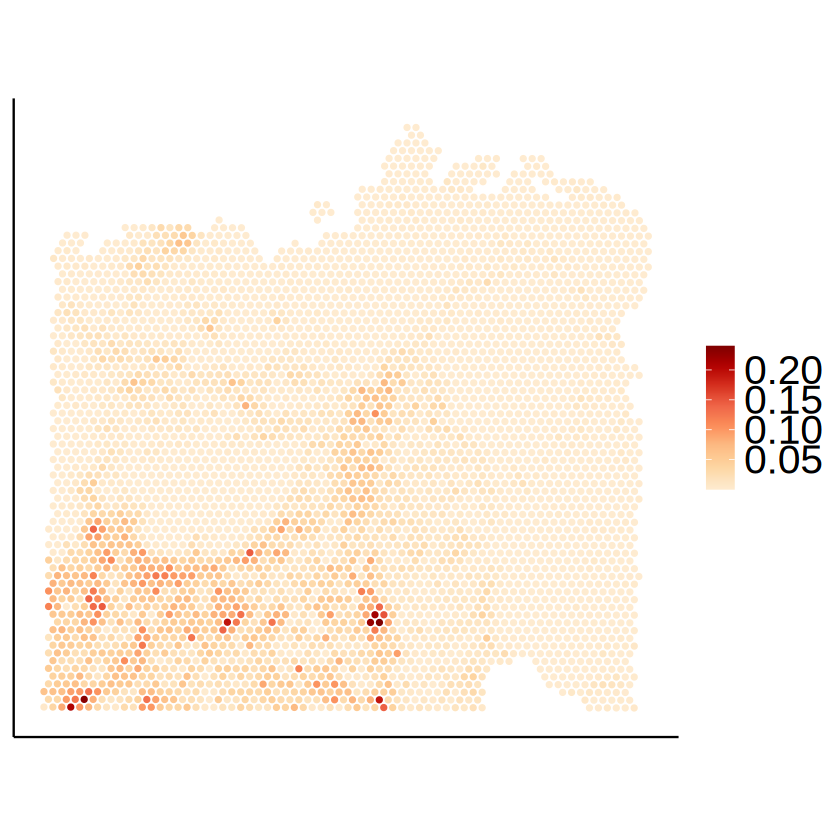

In [6]:
for (celltype in immune_celltypes) {
    p <- mcubePlotPropCellType(
        proportions_RCTD, as.matrix(myRCTD@spatialRNA@coords), celltype
    ) + labs(title = NULL, x = NULL, y = NULL) +
        theme(
            axis.text = element_blank(),
            axis.ticks = element_blank(),
            legend.text = element_text(size = 24),
            legend.position = "right"
        )
    ggsave(
        filename = file.path(
            RESULT_PATH,
            paste0(tech, "_proportion_", celltype, ".pdf")
        ),
        plot = p, width = 7, height = 5
    )
    ggsave(
        filename = file.path(
            RESULT_PATH,
            paste0(tech, "_proportion_", celltype, ".png")
        ),
        plot = p, width = 7, height = 5
    )
}
p

## 10x Visium HD

In [7]:
tech <- "VisiumHD"

### Cell type deconvolution using `RCTD`

In [8]:
myRCTD <- readRDS(file.path(RESULT_PATH, tech, "myRCTD_16um.rds"))
weights_RCTD <- as.matrix(myRCTD@results$weights)
proportions_RCTD <- weights_RCTD / rowSums(weights_RCTD)

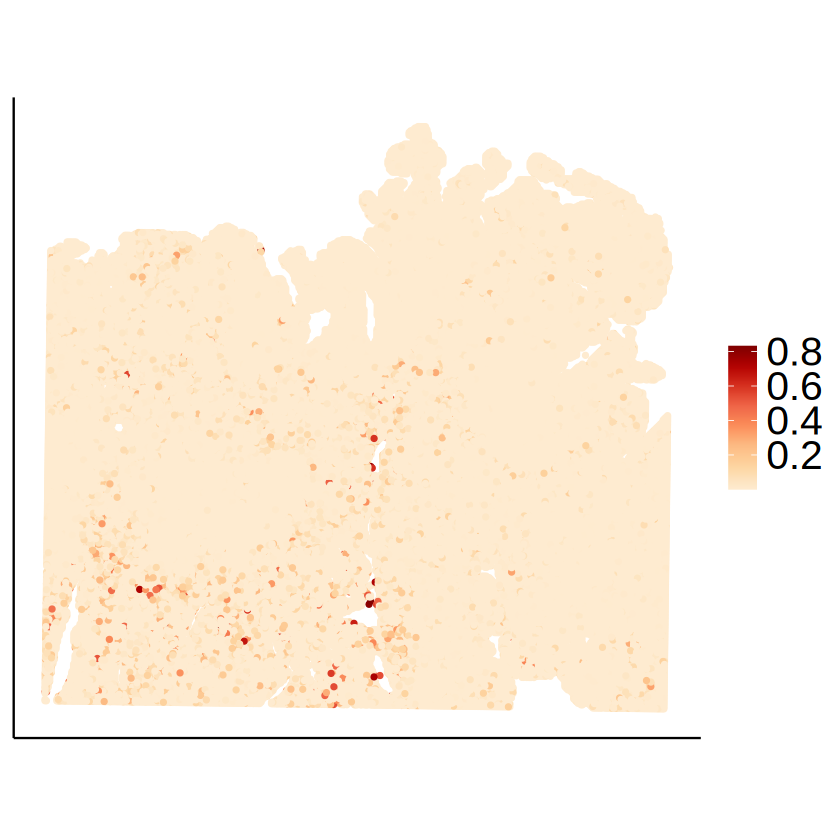

In [9]:
for (celltype in immune_celltypes) {
    p <- mcubePlotPropCellType(
        proportions_RCTD, as.matrix(myRCTD@spatialRNA@coords), 
        celltype, spot_size = 1
    ) + labs(title = NULL, x = NULL, y = NULL) +
        theme(
            plot.title = element_text(size = 24, hjust = 0.5),
            axis.text = element_blank(),
            axis.ticks = element_blank(),
            legend.text = element_text(size = 24),
            legend.position = "right"
        )
    ggsave(
        filename = file.path(
            RESULT_PATH,
            paste0(tech, "_proportion_", celltype, ".pdf")
        ),
        plot = p, width = 7, height = 5
    )
    ggsave(
        filename = file.path(
            RESULT_PATH,
            paste0(tech, "_proportion_", celltype, ".png")
        ),
        plot = p, width = 7, height = 5
    )
}
p

### Cell-type-specific SVG identification using `MCube`

In [10]:
weights_RCTD <- as.matrix(myRCTD@results$weights)
proportions_RCTD <- weights_RCTD / rowSums(weights_RCTD)
spot_effects_RCTD <- log(rowSums(weights_RCTD))
names(spot_effects_RCTD) <- rownames(weights_RCTD)
doublet_results_RCTD <- myRCTD@results$results_df

#### KLRB1 in CD4+ T cell

In [11]:
celltype <- immune_celltypes[1]
gene <- "KLRB1"

In [12]:
mcube_object <- readRDS(
    file.path(
        RESULT_PATH, tech,
        paste0("mcube_", celltype, ".rds")
    )
)
mcube_object@pvalues[[celltype]][gene, ]

,linear,Gaussian_1,Gaussian_2,Gaussian_transformed_1,Gaussian_transformed_2,combined_pvalue
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
KLRB1,0.6554415,2.028479e-07,6.329989e-10,0.3295828,0.2393012,3.155149e-09


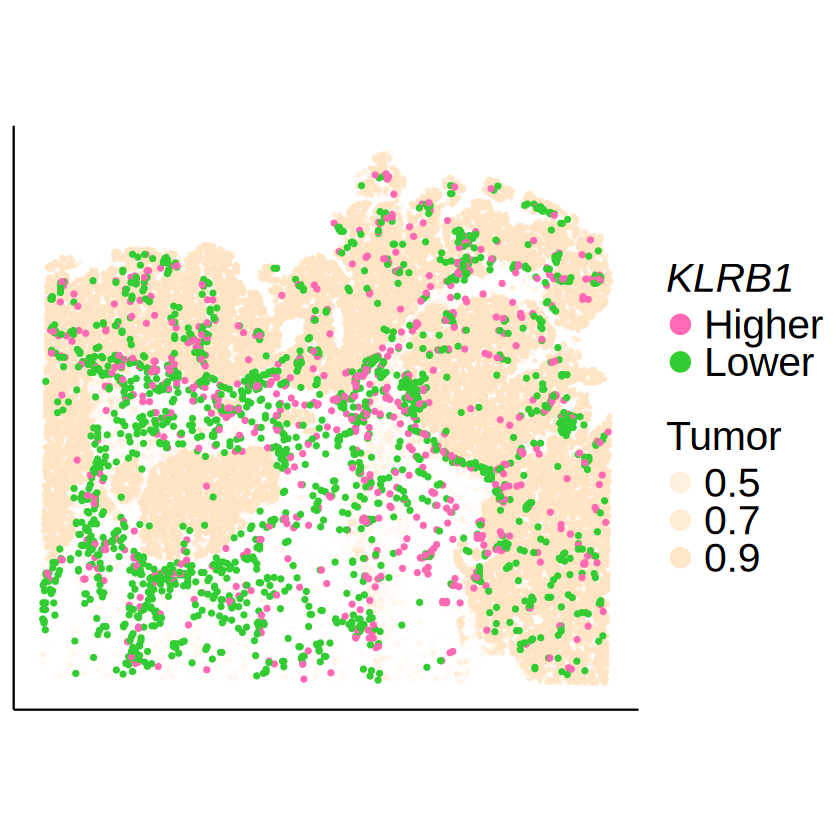

In [13]:
null_model_results <- mcube_object@null_models[[paste0(celltype, "_", gene)]]

spots_target <- null_model_results$spots
expr_level <- null_model_results$u[spots_target, celltype]
expr_level <- factor(ifelse(expr_level >= 0, "Higher", "Lower"))
target_df <- data.frame(
    x = mcube_object@coordinates[spots_target, 1],
    y = mcube_object@coordinates[spots_target, 2],
    expr_level = expr_level
)

spots_background <- setdiff(rownames(proportions_RCTD), spots_target)
tumor_df <- cbind(
    myRCTD@spatialRNA@coords[spots_background, ],
    Tumor = proportions_RCTD[spots_background, "Tumor III"]
)
tumor_df <- tumor_df[sample(1:nrow(tumor_df), 30000), ]

p <- ggplot() +
    geom_point(
        data = tumor_df, 
        aes(x = x, y = y, alpha = Tumor),
        color = "bisque", size = 0.5
    ) +
    geom_point(
        data = target_df,
        aes(x = x, y = y, color = expr_level),
        size = 1, alpha = 1
    ) +
    scale_color_manual(
    #   name = bquote(italic(.(gene)) ~ "expression"),
        name = bquote(italic(.(gene))),
      values = c("Lower" = palettes[1], "Higher" = palettes[2])
    ) +
    scale_alpha_continuous(
        name = "Tumor",
        range = c(0, 1),
        breaks = c(0.5, 0.7, 0.9)
    ) +
    guides(
        color = guide_legend(
            order = 1, override.aes = list(size = 5)),
        alpha = guide_legend(order = 2, override.aes = list(size = 5))
    ) +
    scale_y_continuous(trans = "reverse") +
        coord_fixed(ratio = 1) +
        labs(title = NULL, x = NULL, y = NULL) +
        theme_classic() +
        theme(
            text = element_text(family = "Helvetica"),
            axis.text = element_blank(),
            axis.ticks = element_blank(),
            legend.title = element_text(size = 24),
            legend.text = element_text(size = 24), 
            legend.position = "right"
        )
ggsave(
    filename = file.path(
        RESULT_PATH,
        paste0(tech, "_", celltype, "_", gene, ".pdf")
    ),
    plot = p, width = 7, height = 5
)
ggsave(
    filename = file.path(
        RESULT_PATH,
        paste0(tech, "_", celltype, "_", gene, ".png")
    ),
    plot = p, width = 7, height = 5
)
p

#### GNLY in CD8+ Cytotoxic T cell

In [14]:
celltype <- "CD8 Cytotoxic T cell"
gene <- "GNLY"

In [15]:
mcube_object <- readRDS(
    file.path(
        RESULT_PATH, tech,
        paste0("mcube_", celltype, ".rds")
    )
)
mcube_object@pvalues[[celltype]][gene, ]

,linear,Gaussian_1,Gaussian_2,Gaussian_transformed_1,Gaussian_transformed_2,combined_pvalue
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
GNLY,1.198134e-11,5.41254e-10,6.373048e-14,0.8144249,0.7653016,3.170797e-13


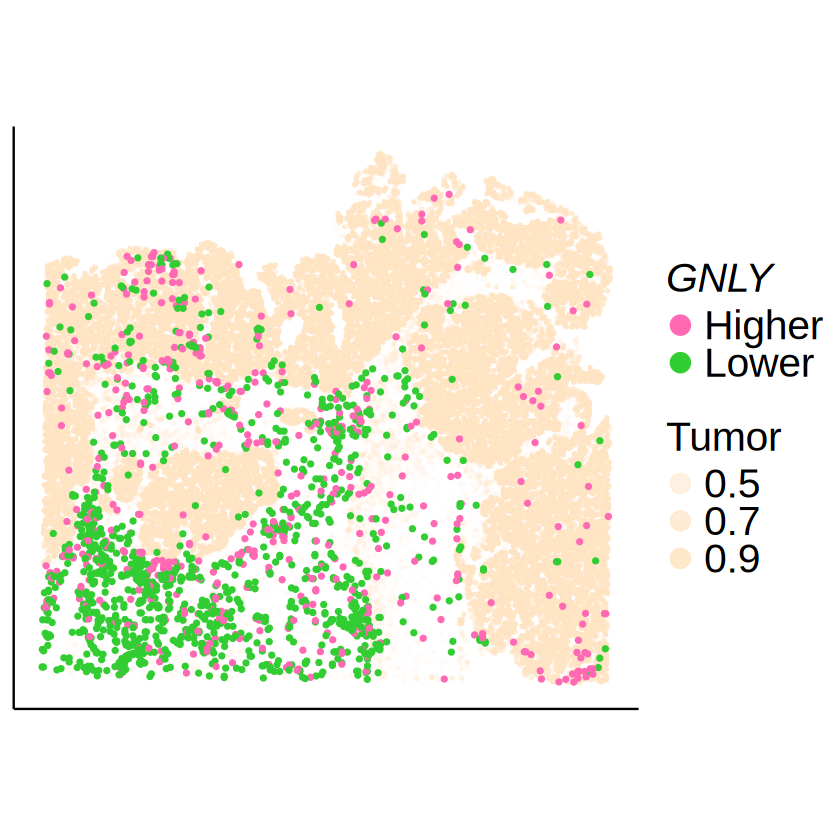

In [16]:
null_model_results <- mcube_object@null_models[[paste0(celltype, "_", gene)]]

spots_target <- null_model_results$spots
expr_level <- null_model_results$u[spots_target, celltype]
expr_level <- factor(ifelse(expr_level >= 0, "Higher", "Lower"))
target_df <- data.frame(
    x = mcube_object@coordinates[spots_target, 1],
    y = mcube_object@coordinates[spots_target, 2],
    expr_level = expr_level
)

spots_background <- setdiff(rownames(proportions_RCTD), spots_target)
tumor_df <- cbind(
    myRCTD@spatialRNA@coords[spots_background, ],
    Tumor = proportions_RCTD[spots_background, "Tumor III"]
)
tumor_df <- tumor_df[sample(1:nrow(tumor_df), 30000), ]

p <- ggplot() +
    geom_point(
        data = tumor_df, 
        aes(x = x, y = y, alpha = Tumor),
        color = "bisque", size = 0.5
    ) +
    geom_point(
        data = target_df,
        aes(x = x, y = y, color = expr_level),
        size = 1, alpha = 1
    ) +
    scale_color_manual(
      #   name = bquote(italic(.(gene)) ~ "expression"),         
      name = bquote(italic(.(gene))),
      values = c("Lower" = palettes[1], "Higher" = palettes[2])
    ) +
    scale_alpha_continuous(
        name = "Tumor",
        range = c(0, 1),
        breaks = c(0.5, 0.7, 0.9)
    ) +
    guides(
        color = guide_legend(
            order = 1, override.aes = list(size = 5)),
        alpha = guide_legend(order = 2, override.aes = list(size = 5))
    ) +
    scale_y_continuous(trans = "reverse") +
        coord_fixed(ratio = 1) +
        labs(title = NULL, x = NULL, y = NULL) +
        theme_classic() +
        theme(
            text = element_text(family = "Helvetica"),
            axis.text = element_blank(),
            axis.ticks = element_blank(),
            legend.title = element_text(size = 24),
            legend.text = element_text(size = 24), 
            legend.position = "right"
        )
ggsave(
    filename = file.path(
        RESULT_PATH,
        paste0(tech, "_", celltype, "_", gene, ".pdf")
    ),
    plot = p, width = 7, height = 5
)
ggsave(
    filename = file.path(
        RESULT_PATH,
        paste0(tech, "_", celltype, "_", gene, ".png")
    ),
    plot = p, width = 7, height = 5
)
p

## 10x Xenium

In [17]:
tech <- "Xenium"

### Cell type deconvolution using `RCTD`

In [18]:
myRCTD <- readRDS(file.path(RESULT_PATH, tech, "myRCTD.rds"))
weights_RCTD <- as.matrix(myRCTD@results$weights)
proportions_RCTD <- weights_RCTD / rowSums(weights_RCTD)

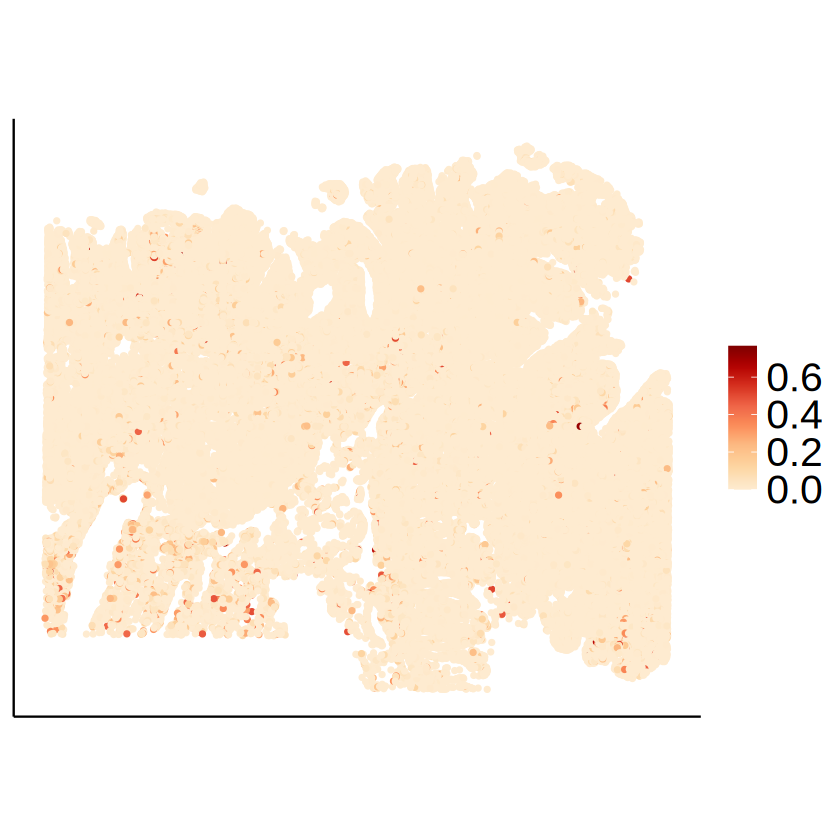

In [19]:
for (celltype in immune_celltypes) {
    p <- mcubePlotPropCellType(
        proportions_RCTD, as.matrix(myRCTD@spatialRNA@coords), 
        celltype, spot_size = 1
    ) + labs(title = NULL, x = NULL, y = NULL) +
        theme(
            plot.title = element_text(size = 24, hjust = 0.5),
            axis.text = element_blank(),
            axis.ticks = element_blank(),
            legend.text = element_text(size = 24),
            legend.position = "right"
        )
    ggsave(
        filename = file.path(
            RESULT_PATH,
            paste0(tech, "_proportion_", celltype, ".pdf")
        ),
        plot = p, width = 7, height = 5
    )
    ggsave(
        filename = file.path(
            RESULT_PATH,
            paste0(tech, "_proportion_", celltype, ".png")
        ),
        plot = p, width = 7, height = 5
    )
}
p

### Cell-type-specific SVG identification using `MCube`

In [20]:
weights_RCTD <- as.matrix(myRCTD@results$weights)
proportions_RCTD <- weights_RCTD / rowSums(weights_RCTD)
spot_effects_RCTD <- log(rowSums(weights_RCTD))
names(spot_effects_RCTD) <- rownames(weights_RCTD)
doublet_results_RCTD <- myRCTD@results$results_df

#### KLRB1 in CD4+ T cell

In [21]:
celltype <- immune_celltypes[1]
gene <- "KLRB1"

In [22]:
mcube_object <- readRDS(
    file.path(
        RESULT_PATH, tech,
        paste0("mcube_", celltype, ".rds")
    )
)
mcube_object@pvalues[[celltype]][gene, ]

,linear,Gaussian_1,Gaussian_2,Gaussian_transformed_1,Gaussian_transformed_2,combined_pvalue
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
KLRB1,0.1773755,5.917171e-19,3.343736e-25,0.002749541,0.000984393,3.343736e-25


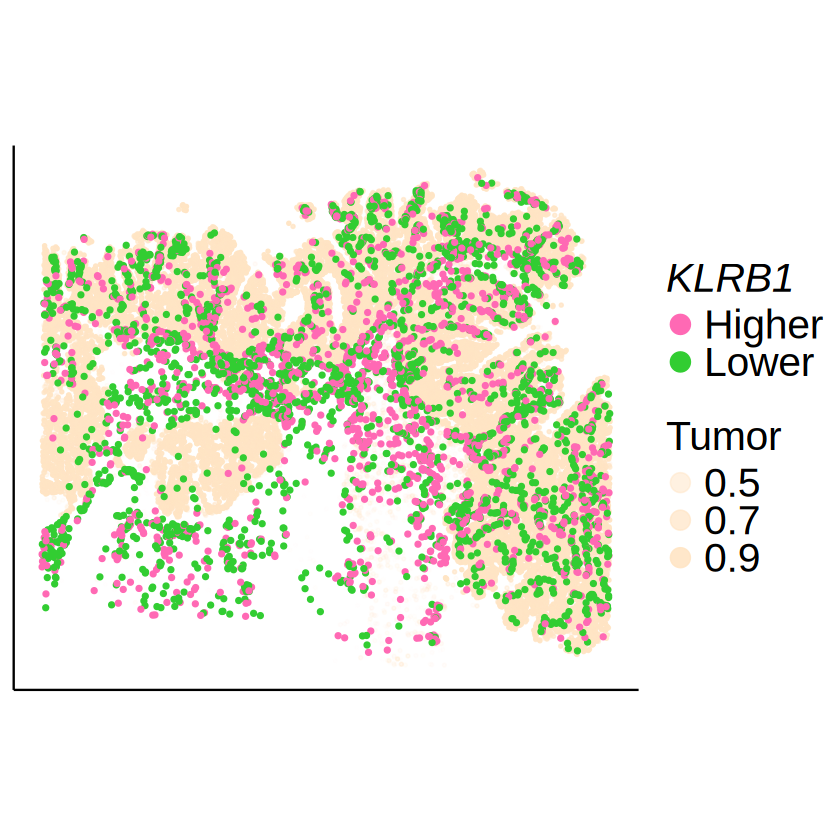

In [23]:
null_model_results <- mcube_object@null_models[[paste0(celltype, "_", gene)]]

spots_target <- null_model_results$spots
expr_level <- null_model_results$u[spots_target, celltype]
expr_level <- factor(ifelse(expr_level >= 0, "Higher", "Lower"))
target_df <- data.frame(
    x = mcube_object@coordinates[spots_target, 1],
    y = mcube_object@coordinates[spots_target, 2],
    expr_level = expr_level
)

spots_background <- setdiff(rownames(proportions_RCTD), spots_target)
tumor_df <- cbind(
    myRCTD@spatialRNA@coords[spots_background, ],
    Tumor = proportions_RCTD[spots_background, "Tumor III"]
)
tumor_df <- tumor_df[sample(1:nrow(tumor_df), 30000), ]

p <- ggplot() +
    geom_point(
        data = tumor_df, 
        aes(x = x, y = y, alpha = Tumor),
        color = "bisque", size = 0.5
    ) +
    geom_point(
        data = target_df,
        aes(x = x, y = y, color = expr_level),
        size = 1, alpha = 1
    ) +
    scale_color_manual(
      #   name = bquote(italic(.(gene)) ~ "expression"),         
      name = bquote(italic(.(gene))),
      values = c("Lower" = palettes[1], "Higher" = palettes[2])
    ) +
    scale_alpha_continuous(
        name = "Tumor",
        range = c(0, 1),
        breaks = c(0.5, 0.7, 0.9)
    ) +
    guides(
        color = guide_legend(
            override.aes = list(size = 5)),
        alpha = guide_legend(override.aes = list(size = 5))
    ) +
    scale_y_continuous(trans = "reverse") +
        coord_fixed(ratio = 1) +
        labs(title = NULL, x = NULL, y = NULL) +
        theme_classic() +
        theme(
            text = element_text(family = "Helvetica"),
            axis.text = element_blank(),
            axis.ticks = element_blank(),
            legend.title = element_text(size = 18),
            legend.text = element_text(size = 24), 
            legend.position = "right"
        )
ggsave(
    filename = file.path(
        RESULT_PATH,
        paste0(tech, "_", celltype, "_", gene, ".pdf")
    ),
    plot = p, width = 7, height = 5
)
ggsave(
    filename = file.path(
        RESULT_PATH,
        paste0(tech, "_", celltype, "_", gene, ".png")
    ),
    plot = p, width = 7, height = 5
)
pnull_model_results <- mcube_object@null_models[[paste0(celltype, "_", gene)]]

spots_target <- null_model_results$spots
expr_level <- null_model_results$u[spots_target, celltype]
expr_level <- factor(ifelse(expr_level >= 0, "Higher", "Lower"))
target_df <- data.frame(
    x = mcube_object@coordinates[spots_target, 1],
    y = mcube_object@coordinates[spots_target, 2],
    expr_level = expr_level
)

spots_background <- setdiff(rownames(proportions_RCTD), spots_target)
tumor_df <- cbind(
    myRCTD@spatialRNA@coords[spots_background, ],
    Tumor = proportions_RCTD[spots_background, "Tumor III"]
)
tumor_df <- tumor_df[sample(1:nrow(tumor_df), 30000), ]

p <- ggplot() +
    geom_point(
        data = tumor_df, 
        aes(x = x, y = y, alpha = Tumor),
        color = "bisque", size = 0.5
    ) +
    geom_point(
        data = target_df,
        aes(x = x, y = y, color = expr_level),
        size = 1, alpha = 1
    ) +
    scale_color_manual(
      #   name = bquote(italic(.(gene)) ~ "expression"),         
      name = bquote(italic(.(gene))),
      values = c("Lower" = palettes[1], "Higher" = palettes[2])
    ) +
    scale_alpha_continuous(
        name = "Tumor",
        range = c(0, 1),
        breaks = c(0.5, 0.7, 0.9)
    ) +
    guides(
        color = guide_legend(
            order = 1, override.aes = list(size = 5)),
        alpha = guide_legend(order = 2, override.aes = list(size = 5))
    ) +
    scale_y_continuous(trans = "reverse") +
        coord_fixed(ratio = 1) +
        labs(title = NULL, x = NULL, y = NULL) +
        theme_classic() +
        theme(
            text = element_text(family = "Helvetica"),
            axis.text = element_blank(),
            axis.ticks = element_blank(),
            legend.title = element_text(size = 24),
            legend.text = element_text(size = 24), 
            legend.position = "right"
        )
ggsave(
    filename = file.path(
        RESULT_PATH,
        paste0(tech, "_", celltype, "_", gene, ".pdf")
    ),
    plot = p, width = 7, height = 5
)
ggsave(
    filename = file.path(
        RESULT_PATH,
        paste0(tech, "_", celltype, "_", gene, ".png")
    ),
    plot = p, width = 7, height = 5
)
p

#### GNLY in CD8+ Cytotoxic T cell

In [24]:
celltype <- "CD8 Cytotoxic T cell"
gene <- "GNLY"

In [25]:
mcube_object <- readRDS(
    file.path(
        RESULT_PATH, tech,
        paste0("mcube_", celltype, ".rds")
    )
)
mcube_object@pvalues[[celltype]][gene, ]

,linear,Gaussian_1,Gaussian_2,Gaussian_transformed_1,Gaussian_transformed_2,combined_pvalue
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
GNLY,8.876639e-26,4.518422e-46,1.832016e-63,0.08656896,0.066333,1.832016e-63


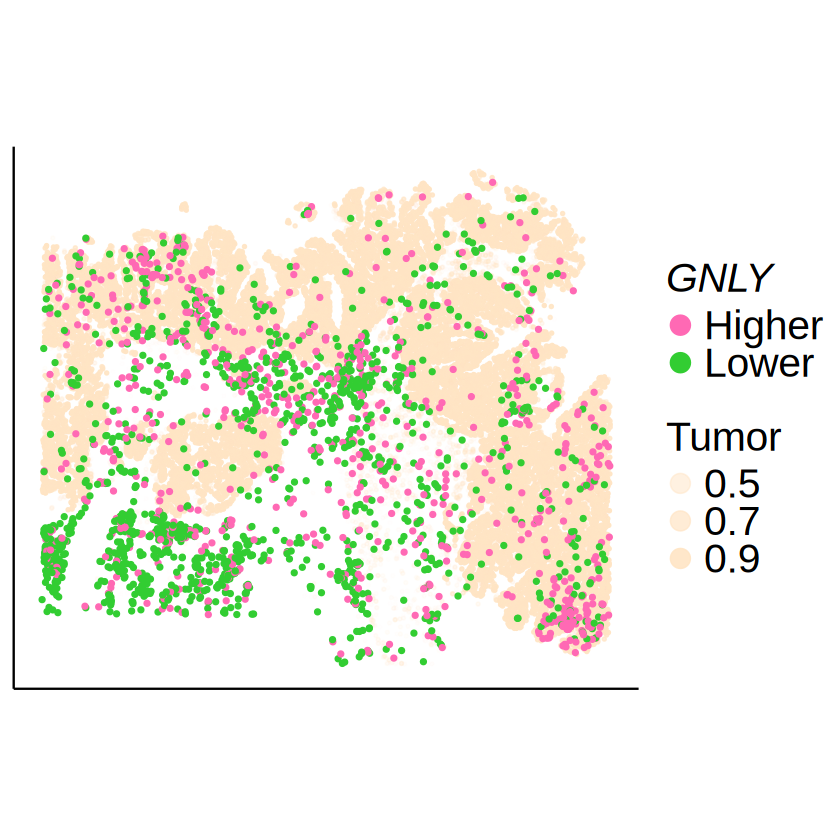

In [26]:
null_model_results <- mcube_object@null_models[[paste0(celltype, "_", gene)]]

spots_target <- null_model_results$spots
expr_level <- null_model_results$u[spots_target, celltype]
expr_level <- factor(ifelse(expr_level >= 0, "Higher", "Lower"))
target_df <- data.frame(
    x = mcube_object@coordinates[spots_target, 1],
    y = mcube_object@coordinates[spots_target, 2],
    expr_level = expr_level
)

spots_background <- setdiff(rownames(proportions_RCTD), spots_target)
tumor_df <- cbind(
    myRCTD@spatialRNA@coords[spots_background, ],
    Tumor = proportions_RCTD[spots_background, "Tumor III"]
)
tumor_df <- tumor_df[sample(1:nrow(tumor_df), 30000), ]

p <- ggplot() +
    geom_point(
        data = tumor_df, 
        aes(x = x, y = y, alpha = Tumor),
        color = "bisque", size = 0.5
    ) +
    geom_point(
        data = target_df,
        aes(x = x, y = y, color = expr_level),
        size = 1, alpha = 1
    ) +
    scale_color_manual(
      #   name = bquote(italic(.(gene)) ~ "expression"),         
      name = bquote(italic(.(gene))),
      values = c("Lower" = palettes[1], "Higher" = palettes[2])
    ) +
    scale_alpha_continuous(
        name = "Tumor",
        range = c(0, 1),
        breaks = c(0.5, 0.7, 0.9)
    ) +
    guides(
        color = guide_legend(
            order = 1, override.aes = list(size = 5)),
        alpha = guide_legend(order = 2, override.aes = list(size = 5))
    ) +
    scale_y_continuous(trans = "reverse") +
        coord_fixed(ratio = 1) +
        labs(title = NULL, x = NULL, y = NULL) +
        theme_classic() +
        theme(
            text = element_text(family = "Helvetica"),
            axis.text = element_blank(),
            axis.ticks = element_blank(),
            legend.title = element_text(size = 24),
            legend.text = element_text(size = 24), 
            legend.position = "right"
        )
ggsave(
    filename = file.path(
        RESULT_PATH,
        paste0(tech, "_", celltype, "_", gene, ".pdf")
    ),
    plot = p, width = 7, height = 5
)
ggsave(
    filename = file.path(
        RESULT_PATH,
        paste0(tech, "_", celltype, "_", gene, ".png")
    ),
    plot = p, width = 7, height = 5
)
p